#  DeepShield Detect — Notebook 2 : Entraînement du Modèle

**Objectif :** Entraîner un modèle **EfficientNet-B4** en transfer learning pour détecter les deepfakes, avec callbacks, courbes d'apprentissage et évaluation finale.

| Paramètre | Valeur |
|---|---|
| Architecture | EfficientNet-B4 (pretrained ImageNet) |
| Stratégie | Transfer Learning + Fine-tuning |
| Optimiseur | Adam |
| Métrique cible | AUC > 0.90 |
| Input | Données `.npy` du Notebook 1 |

---

## Imports & Configuration

On importe TensorFlow/Keras et on fixe toutes les graines aléatoires pour la reproductibilité.

In [3]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint,
    ReduceLROnPlateau, TensorBoard
)
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')

# ── Reproductibilité ──────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Chemins ───────────────────────────────────────────────
PROCESSED_DIR = r'..\data\processed'
MODELS_DIR    = r'..\models'
RESULTS_DIR   = r'..\results'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Hyperparamètres ───────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 32   # réduis à 16 si mémoire insuffisante
EPOCHS_HEAD = 10   # Phase 1 : tête seulement
EPOCHS_FINE = 20   # Phase 2 : fine-tuning
LR_HEAD     = 1e-3
LR_FINE     = 1e-5

print('TensorFlow :', tf.__version__)
print('GPU dispo  :', tf.config.list_physical_devices('GPU'))
print('Config OK ')

TensorFlow : 2.21.0
GPU dispo  : []
Config OK 


---
## Chargement des Données

On charge les 6 fichiers `.npy` produits par le Notebook 1.  
Les données sont déjà normalisées `[0, 1]` et splittées — rien à refaire.

In [4]:
print('Chargement des données...')

X_train = np.load(os.path.join(PROCESSED_DIR, 'X_train.npy'))
X_val   = np.load(os.path.join(PROCESSED_DIR, 'X_val.npy'))
X_test  = np.load(os.path.join(PROCESSED_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(PROCESSED_DIR, 'y_train.npy'))
y_val   = np.load(os.path.join(PROCESSED_DIR, 'y_val.npy'))
y_test  = np.load(os.path.join(PROCESSED_DIR, 'y_test.npy'))

print(f'X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}  |  y_val   : {y_val.shape}')
print(f'X_test  : {X_test.shape}  |  y_test  : {y_test.shape}')
print(f'\nClasses → 0=REAL : {sum(y_train==0)}  |  1=FAKE : {sum(y_train==1)}')
print(' Données chargées.')

Chargement des données...
X_train : (2797, 224, 224, 3)  |  y_train : (2797,)
X_val   : (599, 224, 224, 3)  |  y_val   : (599,)
X_test  : (600, 224, 224, 3)  |  y_test  : (600,)

Classes → 0=REAL : 1398  |  1=FAKE : 1399
 Données chargées.


---
##  Data Augmentation

L'augmentation de données génère des variations artificielles des images d'entraînement (flip, rotation, zoom...).  
Cela **réduit l'overfitting** et améliore la généralisation du modèle.  
Elle est appliquée **uniquement sur le train set**, jamais sur val/test.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0202963].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0162733].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0083846].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0172554].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0197403].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0048519].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0035722].


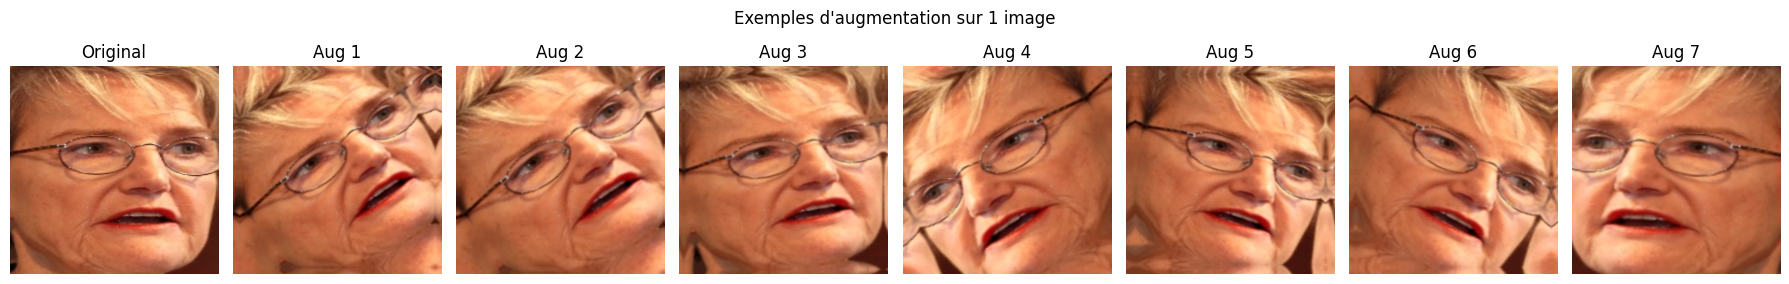

 Augmentation configurée.


In [5]:
# ── Couche d'augmentation intégrée dans le modèle ────────
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='data_augmentation')

# ── Visualiser l'effet de l'augmentation ─────────────────
sample = X_train[:1]   # 1 image
fig, axes = plt.subplots(1, 8, figsize=(18, 3))
fig.suptitle('Exemples d\'augmentation sur 1 image', fontsize=12)

axes[0].imshow(sample[0])
axes[0].set_title('Original')
axes[0].axis('off')

for i in range(1, 8):
    aug = data_augmentation(sample, training=True)
    axes[i].imshow(aug[0].numpy())
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'augmentation_examples.png'), dpi=150)
plt.show()
print(' Augmentation configurée.')

---
##  Construction du Modèle EfficientNet-B4

On utilise la stratégie **Transfer Learning en 2 phases** :

| Phase | Couches entraînées | Epochs | Learning Rate |
|---|---|---|---|
| Phase 1 — Head | Tête seulement (base gelée) | 10 | 1e-3 |
| Phase 2 — Fine-tuning | 30 dernières couches dégel | 20 | 1e-5 |

**Pourquoi EfficientNet-B4 ?** Excellent compromis précision/vitesse, conçu pour la détection de patterns subtils comme les artefacts deepfake.

In [6]:
def build_model(img_size=IMG_SIZE, learning_rate=LR_HEAD):
    """
    Construit le modèle EfficientNet-B4 avec tête de classification.
    La base EfficientNet est gelée pour la Phase 1.
    """
    # ── Base pré-entraînée (ImageNet) ─────────────────────
    base_model = EfficientNetB4(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3)
    )
    base_model.trainable = False   # gelé en Phase 1

    # ── Tête de classification ────────────────────────────
    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = data_augmentation(inputs, training=True)  # augmentation
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)  # binaire

    model = Model(inputs, outputs, name='DeepShield_EfficientNetB4')

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model, base_model

model, base_model = build_model()
model.summary()
print(f'\nTotal params     : {model.count_params():,}')
print(f'Trainable params : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')

Model: "DeepShield_EfficientNetB4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 7, 7, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1792)           │         7,168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       459,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,156,512 (69.26 MB)

 Trainable params: 479,105 (1.83 MB)

 Non-trainable params: 17,677,407 (67.43 MB)


Total params     : 18,156,512
Trainable params : 479,105


---
##  Callbacks

Les callbacks contrôlent l'entraînement automatiquement :

| Callback | Rôle |
|---|---|
| `ModelCheckpoint` | Sauvegarde le meilleur modèle (val_auc) |
| `EarlyStopping` | Stoppe si plus de progrès (patience=5) |
| `ReduceLROnPlateau` | Réduit le LR si plateau détecté |
| `TensorBoard` | Logs pour visualisation (optionnel) |

In [7]:
BEST_MODEL_PATH = os.path.join(MODELS_DIR, 'deepshield_best.keras')

callbacks_phase1 = [
    ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_auc',
        patience=5,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

# Mêmes callbacks pour la phase 2
callbacks_phase2 = callbacks_phase1.copy()

print(' Callbacks configurés.')
print(f'   Meilleur modèle sauvegardé dans : {BEST_MODEL_PATH}')

 Callbacks configurés.
   Meilleur modèle sauvegardé dans : ..\models\deepshield_best.keras


---
## Phase 1 : Entraînement de la Tête

On entraîne **uniquement la tête de classification** (la base EfficientNet est gelée).  
Durée estimée : **5 à 15 min** selon CPU/GPU.  
Objectif Phase 1 : val_accuracy > 0.80

In [8]:
print('=' * 55)
print('PHASE 1 — Entraînement de la tête (base gelée)')
print('=' * 55)

history_phase1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_HEAD,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_phase1,
    verbose=1
)

print('\n Phase 1 terminée.')
val_auc_p1 = max(history_phase1.history['val_auc'])
print(f'   Meilleure val_AUC Phase 1 : {val_auc_p1:.4f}')

PHASE 1 — Entraînement de la tête (base gelée)
Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4953 - auc: 0.4990 - loss: 1.1208 - precision: 0.5054 - recall: 0.5031
Epoch 1: val_auc improved from None to 0.50000, saving model to ..\models\deepshield_best.keras

Epoch 1: finished saving model to ..\models\deepshield_best.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.5048 - auc: 0.5050 - loss: 1.0677 - precision: 0.5051 - recall: 0.4996 - val_accuracy: 0.5008 - val_auc: 0.5000 - val_loss: 0.6932 - val_precision: 0.5008 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4837 - auc: 0.4831 - loss: 0.8346 - precision: 0.4950 - recall: 0.4868
Epoch 2: val_auc did not improve from 0.50000
88/88 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.4859 - auc: 0.4781 - loss: 0.7980 - precision: 0.4864 - recall: 0.4968 - val_accuracy: 0.5008 - val_auc: 0.5000 - val_loss: 0.6931 - val_precision: 0.5008 - val_recall:

---
## Phase 2 : Fine-tuning

On dégèle les **30 dernières couches** de EfficientNet-B4 et on ré-entraîne avec un **learning rate très faible** (1e-5) pour affiner les features sans détruire les poids pré-entraînés.

Durée estimée : **15 à 40 min** selon CPU/GPU.  
Objectif Phase 2 : val_AUC > 0.90 

In [9]:
print('=' * 55)
print('PHASE 2 — Fine-tuning (30 dernières couches)')
print('=' * 55)

# Dégeler les 30 dernières couches
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'Params entraînables après dégel : {trainable_count:,}')

# Recompiler avec LR plus faible
model.compile(
    optimizer=Adam(learning_rate=LR_FINE),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

history_phase2 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FINE,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_phase2,
    verbose=1
)

print('\n Phase 2 terminée.')
val_auc_p2 = max(history_phase2.history['val_auc'])
print(f'   Meilleure val_AUC Phase 2 : {val_auc_p2:.4f}')

PHASE 2 — Fine-tuning (30 dernières couches)
Params entraînables après dégel : 5,311,605
Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5251 - auc: 0.5294 - loss: 0.7782 - precision: 0.5342 - recall: 0.5207
Epoch 1: val_auc improved from 0.50000 to 0.53574, saving model to ..\models\deepshield_best.keras

Epoch 1: finished saving model to ..\models\deepshield_best.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.5095 - auc: 0.5121 - loss: 0.7898 - precision: 0.5098 - recall: 0.5011 - val_accuracy: 0.5008 - val_auc: 0.5357 - val_loss: 0.6934 - val_precision: 0.5008 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4988 - auc: 0.5043 - loss: 0.7827 - precision: 0.5093 - recall: 0.4877
Epoch 2: val_auc did not improve from 0.53574
88/88 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.4987 - auc: 0.4973 - loss: 0.7912 - precision: 0.4989 - recall: 0.4882 - val_accuracy: 0.5008 - val_auc: 0.5231 - val_l

---
## Courbes d'Apprentissage

On visualise l'évolution de la **loss**, de l'**accuracy** et de l'**AUC** sur les deux phases combinées.  
Une bonne courbe montre : train et val qui convergent sans trop d'écart (signe d'overfitting).

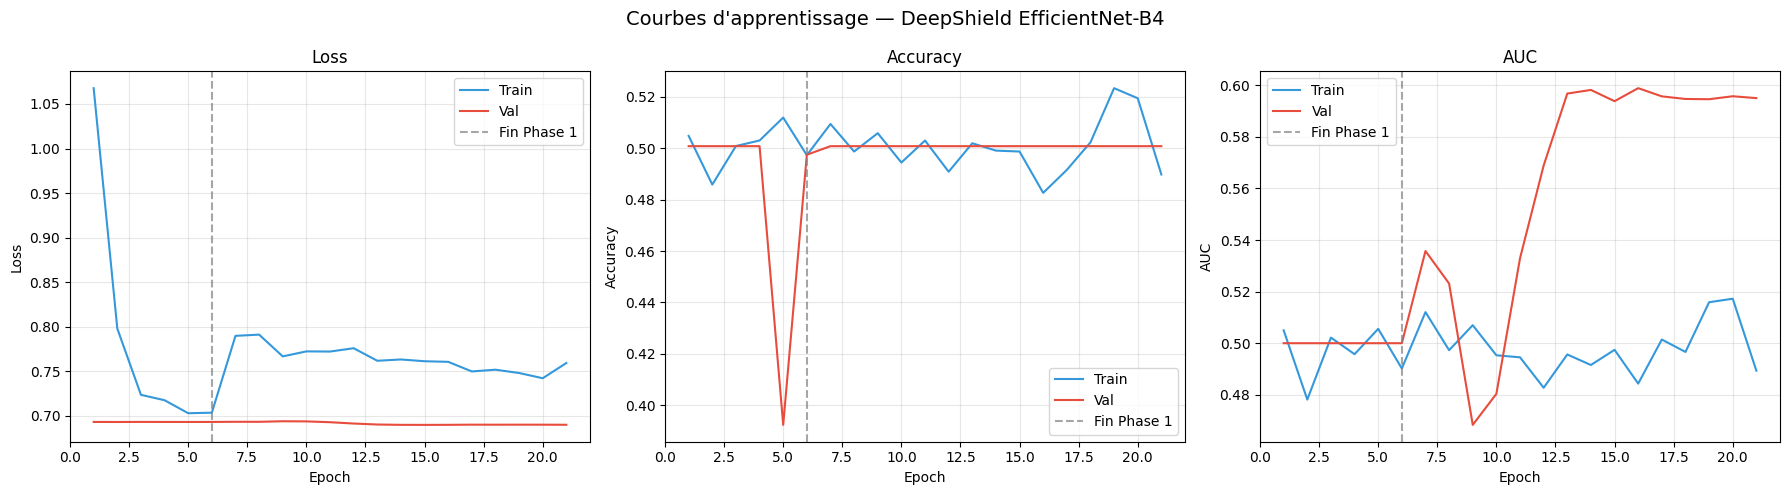

 Courbes sauvegardées dans results/


In [10]:
def merge_history(h1, h2):
    """Fusionne les historiques Phase 1 et Phase 2."""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

history = merge_history(history_phase1, history_phase2)
epochs_range = range(1, len(history['loss']) + 1)
p1_end = len(history_phase1.history['loss'])  # repère fin Phase 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Courbes d\'apprentissage — DeepShield EfficientNet-B4', fontsize=14)

metrics = [
    ('loss',     'Loss',     'Loss'),
    ('accuracy', 'Accuracy', 'Accuracy'),
    ('auc',      'AUC',      'AUC'),
]

for ax, (metric, title, ylabel) in zip(axes, metrics):
    ax.plot(epochs_range, history[metric],     label='Train', color='#3498db')
    ax.plot(epochs_range, history[f'val_{metric}'], label='Val',   color='#e74c3c')
    ax.axvline(x=p1_end, color='gray', linestyle='--', alpha=0.7, label='Fin Phase 1')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'learning_curves.png'), dpi=150)
plt.show()
print(' Courbes sauvegardées dans results/')

---
## Évaluation sur le Test Set

On charge le **meilleur modèle sauvegardé** et on l'évalue sur le test set (jamais vu pendant l'entraînement).  
C'est le score officiel à mentionner dans ton rapport.

In [11]:
# Charger le meilleur modèle
best_model = keras.models.load_model(BEST_MODEL_PATH)
print(f' Meilleur modèle chargé depuis : {BEST_MODEL_PATH}')

# Évaluation globale
print('\nÉvaluation sur le TEST SET...')
results = best_model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)
metrics_names = best_model.metrics_names

print('\n' + '='*40)
print('RÉSULTATS FINAUX — Test Set')
print('='*40)
for name, val in zip(metrics_names, results):
    print(f'  {name:12s} : {val:.4f}')

# Prédictions
y_pred_proba = best_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).flatten()
y_pred       = (y_pred_proba >= 0.5).astype(int)

# AUC sklearn (plus précis)
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f'\n  AUC (sklearn) : {auc_score:.4f}')

if auc_score >= 0.90:
    print('\n OBJECTIF ATTEINT : AUC ≥ 0.90 ')
else:
    print(f'\n AUC = {auc_score:.4f} — Voir section fine-tuning pour améliorer')

 Meilleur modèle chargé depuis : ..\models\deepshield_best.keras

Évaluation sur le TEST SET...

RÉSULTATS FINAUX — Test Set
  loss         : 0.6901
  compile_metrics : 0.5000

  AUC (sklearn) : 0.5891

 AUC = 0.5891 — Voir section fine-tuning pour améliorer


---
## Matrice de Confusion & Rapport de Classification

La **matrice de confusion** montre les vrais/faux positifs et négatifs.  
Le **rapport de classification** donne précision, rappel et F1-score par classe.

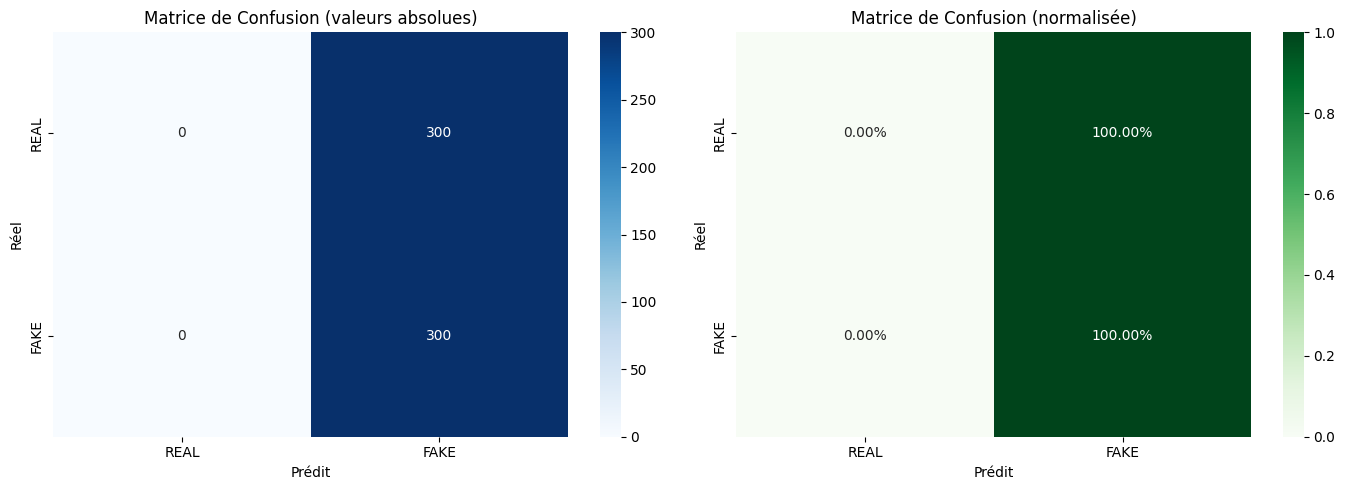


Rapport de classification :
              precision    recall  f1-score   support

        REAL       0.00      0.00      0.00       300
        FAKE       0.50      1.00      0.67       300

    accuracy                           0.50       600
   macro avg       0.25      0.50      0.33       600
weighted avg       0.25      0.50      0.33       600



In [12]:
# ── Matrice de confusion ──────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice absolue
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['REAL', 'FAKE'],
            yticklabels=['REAL', 'FAKE'], ax=axes[0])
axes[0].set_title('Matrice de Confusion (valeurs absolues)')
axes[0].set_xlabel('Prédit')
axes[0].set_ylabel('Réel')

# Matrice normalisée
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['REAL', 'FAKE'],
            yticklabels=['REAL', 'FAKE'], ax=axes[1])
axes[1].set_title('Matrice de Confusion (normalisée)')
axes[1].set_xlabel('Prédit')
axes[1].set_ylabel('Réel')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

# ── Rapport de classification ─────────────────────────────
print('\nRapport de classification :')
print(classification_report(y_test, y_pred, target_names=['REAL', 'FAKE']))

---
## Courbe ROC

La **courbe ROC** (Receiver Operating Characteristic) illustre le compromis entre le taux de vrais positifs et le taux de faux positifs à différents seuils de décision.  
**AUC = 1.0** = modèle parfait | **AUC = 0.5** = aléatoire.

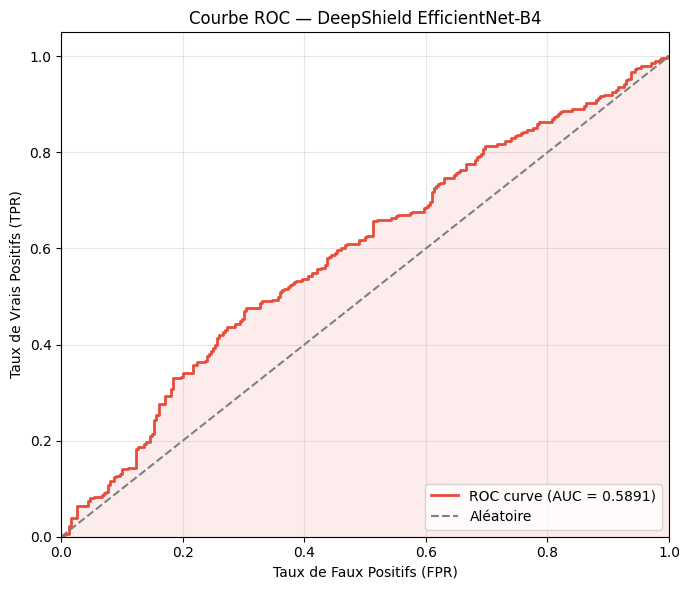

 Courbe ROC sauvegardée dans results/


In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2,
         label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aléatoire')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC — DeepShield EfficientNet-B4')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curve.png'), dpi=150)
plt.show()
print(' Courbe ROC sauvegardée dans results/')

---
##  Sauvegarde Finale du Modèle

On sauvegarde le modèle en 2 formats :
- **`.keras`** : format natif Keras, pour recharger et continuer l'entraînement
- **`.h5`** : format legacy, compatible avec TensorFlow Serving et d'autres outils

On sauvegarde aussi un récapitulatif des métriques en `.csv`.

In [15]:
# ── Sauvegarde finale ─────────────────────────────────────
final_keras_path = os.path.join(MODELS_DIR, 'deepshield_final.keras')

best_model.save(final_keras_path)
print(f' Modèle sauvegardé : {final_keras_path}')

# ── Récapitulatif métriques ───────────────────────────────
metrics_dict = dict(zip(metrics_names, results))
metrics_dict['auc_sklearn'] = auc_score

df_metrics   = pd.DataFrame([metrics_dict])
metrics_path = os.path.join(RESULTS_DIR, 'metrics_summary.csv')
df_metrics.to_csv(metrics_path, index=False)
print(f' Métriques sauvegardées : {metrics_path}')
print('\n' + df_metrics.to_string(index=False))

print('\n' + '='*50)
print(' Notebook 2 terminé !')
print('   → Prochain fichier : notebooks/03_gradcam.ipynb')
print('='*50)

 Modèle sauvegardé : ..\models\deepshield_final.keras
 Métriques sauvegardées : ..\results\metrics_summary.csv

    loss  compile_metrics  auc_sklearn
0.690053              0.5     0.589089

 Notebook 2 terminé !
   → Prochain fichier : notebooks/03_gradcam.ipynb


---
##  Récapitulatif — Ce qui a été produit

| Fichier | Contenu |
|---|---|
| `models/deepshield_best.keras` | Meilleur modèle (checkpoint) |
| `models/deepshield_final.keras` | Modèle final format Keras |
| `models/deepshield_final.h5` | Modèle final format H5 |
| `results/augmentation_examples.png` | Exemples d'augmentation |
| `results/learning_curves.png` | Courbes loss / accuracy / AUC |
| `results/confusion_matrix.png` | Matrice de confusion |
| `results/roc_curve.png` | Courbe ROC |
| `results/metrics_summary.csv` | Tableau des métriques finales |

**Prochain notebook :** `03_gradcam.ipynb` — Visualisation Grad-CAM des zones détectées